<a href="https://colab.research.google.com/github/KarlyHdzC/Mineria_de_datos/blob/main/F07_Segmentacion_clientes_KBHC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Universidad Anáhuac Puebla**

Dr. Farid Krayem Pineda
Minería de Datos

**Alumna:** Karla Beatriz Hernández Castro



> **F07 - Reto ABR – Segmentación de clientes**

## 1. Contexto:

Una empresa cuenta con información histórica sobre el comportamiento, perfil y respuesta comercial de sus clientes. Sin embargo, actualmente trata a todos sus clientes de manera casi uniforme, lo que limita la efectividad de sus campañas, promociones y estrategias de fidelización. La dirección de marketing necesita descubrir segmentos significativos de clientes para diseñar acciones diferenciadas.

Desde la perspectiva del negocio, este análisis **no busca únicamente aplicar clustering**, sino **identificar segmentos de clientes útiles y defendibles que permitan orientar decisiones de marketing**.

En particular, interesa distinguir qué clientes conviene fidelizar, cuáles responden mejor a promociones, qué perfiles requieren reactivación y cuáles presentan comportamientos atípicos.

Para ello, en este notebook se comparan **K-Means**, orientado a la formación de grupos compactos e interpretables, y **DBSCAN**, útil para detectar estructuras por densidad y observaciones atípicas. Así, el propósito final es convertir los hallazgos técnicos en acciones concretas para la empresa.

## 2. Dataset a analizar

**Customer Personality Analysis
Analysis of company's ideal customers**

https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

Variables disponibles:

*   ingreso
*   estructura familiar
*   montos de compra por categoría
*   frecuencia de compra
*   campañas aceptadas
*   recencia
*   visitas web
*   entre otras






En esta sección se obtiene el conjunto de datos desde Kaggle mediante kagglehub, con el fin de trabajar directamente sobre la fuente sugerida en el reto y facilitar la reproducibilidad del análisis.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "marketing_campaign.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "imakash3011/customer-personality-analysis",
  file_path,
  pandas_kwargs={'sep': '\t'}
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("Imprimir primeros 5 registros:", df.head())

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
Imprimir primeros 5 registros:      ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...         

Importar librerías para el análisis de los clusters y el manejo de df

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 3. Análisis exploratorio (EDA)

En esta sección se revisa la estructura del dataset, tipos de datos, valores faltantes, variables constantes y algunas señales de posible ruido u outliers.

Esto es importante porque el clustering es muy sensible a la calidad de los datos y a la escala de las variables.

In [3]:
# Información general
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
display(df.dtypes)

print("\nResumen estadístico de variables numéricas:")
display(df.describe().T)

Dimensiones: (2240, 29)

Tipos de datos:


,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64



Resumen estadístico de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
ID,"2,240.00","5,592.16","3,246.66",0.00,"2,828.25","5,458.50","8,427.75","11,191.00"
Year_Birth,"2,240.00","1,968.81",11.98,"1,893.00","1,959.00","1,970.00","1,977.00","1,996.00"
Income,"2,216.00","52,247.25","25,173.08","1,730.00","35,303.00","51,381.50","68,522.00","666,666.00"
Kidhome,"2,240.00",0.44,0.54,0.00,0.00,0.00,1.00,2.00
Teenhome,"2,240.00",0.51,0.54,0.00,0.00,0.00,1.00,2.00
Recency,"2,240.00",49.11,28.96,0.00,24.00,49.00,74.00,99.00
MntWines,"2,240.00",303.94,336.60,0.00,23.75,173.50,504.25,"1,493.00"
MntFruits,"2,240.00",26.30,39.77,0.00,1.00,8.00,33.00,199.00
MntMeatProducts,"2,240.00",166.95,225.72,0.00,16.00,67.00,232.00,"1,725.00"
MntFishProducts,"2,240.00",37.53,54.63,0.00,3.00,12.00,50.00,259.00


In [4]:
# Valores faltantes
nulos = df.isnull().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]

print("Valores nulos por columna:")
if len(nulos) > 0:
    display(nulos.to_frame(name="Cantidad de nulos"))
else:
    print("No hay nulos")

Valores nulos por columna:


,Cantidad de nulos
Income,24


In [5]:
# Variables constantes o casi constantes
nunique = df.nunique().sort_values()
constantes = nunique[nunique == 1]

print("Variables constantes:")
display(constantes.to_frame("n_valores_unicos"))

print("\nCategorías de Education:")
display(df["Education"].value_counts())

print("\nCategorías de Marital_Status:")
display(df["Marital_Status"].value_counts())

Variables constantes:


,n_valores_unicos
Z_Revenue,1
Z_CostContact,1



Categorías de Education:


,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54



Categorías de Marital_Status:


,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


## 4. Criterios de limpieza y selección de variables

Antes de aplicar clustering, es necesario definir qué variables realmente ayudan a diferenciar a los clientes. Por ello, se priorizan variables relacionadas con ingreso, comportamiento de compra, respuesta a campañas y actividad reciente, y se excluyen aquellas que no aportan a la segmentación o que funcionan mejor para describir los clusters una vez obtenidos.

### 4.1 Variables excluidas del clustering

Las siguientes variables no se incorporarán directamente al proceso de clustering:

- **ID**: fse excluye porque solo funciona como identificador del cliente.
- **Z_CostContact** y **Z_Revenue**: e eliminan porque son variables constantes y no aportan información para segmentar.
- **Year_Birth**: no se usa directamente, ya que es más útil transformarla en la variable edad.
- **Dt_Customer**: tampoco se usa de forma directa; se transforma en una medida de antigüedad del cliente.
- **Education** y **Marital_Status**: se reservan para describir los clusters después, pero no para construirlos.
- **Complain**: se excluye porque tiene poca variación y no aporta mucho a la segmentación.
- **AcceptedCmp1** a **AcceptedCmp5** y **Response**: no se analizan por separado, sino que se agrupan en una sola variable para representar la aceptación total de campañas.

### 4.2 Variables transformadas o construidas

Con el fin de mejorar la interpretabilidad del análisis y representar de manera más sintética el comportamiento de los clientes, se construirán las siguientes variables derivadas:

- **Age**: se calcula a partir de Year_Birth para representar la edad del cliente de una forma más clara.
- **Customer_Days**: e construye a partir de Dt_Customer para medir la antigüedad del cliente dentro de la empresa.
- **Children**: nse obtiene sumando Kidhome y Teenhome, para tener en una sola variable el número total de hijos en el hogar.
- **Total_Spending**: se calcula sumando los montos gastados en las distintas categorías de productos, con el fin de representar el gasto total del cliente.
- **AcceptedTotal**: se construye agrupando las variables de campañas aceptadas y respuesta final, para resumir en una sola variable el nivel de respuesta promocional del cliente.

Estas transformaciones permiten reducir redundancia, simplificar la interpretación y trabajar con variables más cercanas al problema de negocio.

### 4.3 Variables finales para clustering

Con base en los criterios anteriores, el clustering se realizará sobre una combinación de variables numéricas que reflejan valor económico, comportamiento de compra, actividad comercial y estructura familiar del cliente. Las variables seleccionadas son:

- `Income`
- `Age`
- `Children`
- `Recency`
- `Total_Spending`
- `NumWebPurchases`
- `NumCatalogPurchases`
- `NumStorePurchases`
- `NumDealsPurchases`
- `NumWebVisitsMonth`
- `AcceptedTotal`
- `Customer_Days`

Esta selección busca que los segmentos obtenidos sean interpretables desde la perspectiva de marketing y suficientemente útiles para apoyar decisiones de fidelización, promociones y reactivación de clientes.

In [6]:
# Variables excluidas o transformadas
excluded_vars = [
    "ID",
    "Z_CostContact",
    "Z_Revenue",
    "Year_Birth",
    "Dt_Customer",
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

# Variables finales definidas para clustering
cluster_cols = [
    "Income",
    "Age",
    "Children",
    "Recency",
    "Total_Spending",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "AcceptedTotal",
    "Customer_Days"
]

print("Variables excluidas o transformadas:")
print(excluded_vars)

print("\nVariables finales para clustering:")
print(cluster_cols)

Variables excluidas o transformadas:
['ID', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'Dt_Customer', 'Education', 'Marital_Status', 'Complain', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

Variables finales para clustering:
['Income', 'Age', 'Children', 'Recency', 'Total_Spending', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases', 'NumWebVisitsMonth', 'AcceptedTotal', 'Customer_Days']


### 4.4 Justificación

La selección de variables no busca usar todas las que existen, sino elegir las que realmente ayudan a encontrar diferencias entre los clientes. Por eso, se tomaron variables relacionadas con el valor del cliente, su forma de compra, su respuesta a campañas y su actividad reciente con la empresa.
Las variables que se excluyen no significa que no sirvan, sino que no son las más adecuadas para formar los clusters directamente. Algunas se dejan fuera porque solo identifican al cliente, porque no cambian entre registros o porque es mejor usarlas después para describir los segmentos. Así, el clustering se hace con variables más claras y fáciles de interpretar.

## 5. Preprocesamiento y construcción de la matriz para clustering

Después de definir las variables que se usarán en la segmentación, el siguiente paso es preparar los datos. En esta etapa se tratan los valores faltantes, se construyen nuevas variables más fáciles de interpretar y se arma la matriz final que servirá como entrada para los algoritmos de clustering.


### 5.1 Tratamiento de valores faltantes

En el análisis exploratorio se observó que la única variable con valores faltantes es `Income`, con 24 registros incompletos. Como esta cantidad es pequeña en comparación con el total de datos, se decidió eliminar esos casos para evitar problemas en el análisis.

In [7]:
data = df.copy()

print("Dimensiones originales:", data.shape)

data = data.dropna(subset=["Income"]).copy()

print("Dimensiones después de eliminar nulos en Income:", data.shape)

missing_after = data.isnull().sum()
missing_after = missing_after[missing_after > 0]

print("\nValores faltantes restantes:")
if len(missing_after) > 0:
    display(missing_after.to_frame(name="Cantidad de valores faltantes"))
else:
    print("No hay valores faltantes.")

Dimensiones originales: (2240, 29)
Dimensiones después de eliminar nulos en Income: (2216, 29)

Valores faltantes restantes:
No hay valores faltantes.


### 5.2 Transformación y construcción de variables

Para que la segmentación sea más clara, algunas variables se transforman en indicadores más fáciles de interpretar. Por ejemplo, se calcula la edad, la antigüedad del cliente, el número total de hijos, el gasto total y la cantidad total de campañas aceptadas.

In [8]:
# Conversión de fecha
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], format="%d-%m-%Y")

# Fecha de referencia: la más reciente del dataset
reference_date = data["Dt_Customer"].max()
reference_year = reference_date.year

# Variables derivadas
data["Age"] = reference_year - data["Year_Birth"]
data["Customer_Days"] = (reference_date - data["Dt_Customer"]).dt.days
data["Children"] = data["Kidhome"] + data["Teenhome"]

spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]
data["Total_Spending"] = data[spend_cols].sum(axis=1)

data["AcceptedTotal"] = (
    data["AcceptedCmp1"] + data["AcceptedCmp2"] + data["AcceptedCmp3"] +
    data["AcceptedCmp4"] + data["AcceptedCmp5"] + data["Response"]
)

display(data[["Age", "Customer_Days", "Children", "Total_Spending", "AcceptedTotal"]].head())

,Age,Customer_Days,Children,Total_Spending,AcceptedTotal
0,57,663,0,1617,1
1,60,113,2,27,0
2,49,312,0,776,0
3,30,139,1,53,0
4,33,161,1,422,0


### 5.3 Revisión rápida de las nuevas variables

Una vez construidas las nuevas variables, se revisan sus estadísticas generales para comprobar que los valores tengan sentido antes de continuar con el clustering.

,count,mean,std,min,25%,50%,75%,max
Income,"2,216.00","52,247.25","25,173.08","1,730.00","35,303.00","51,381.50","68,522.00","666,666.00"
Age,"2,216.00",45.18,11.99,18.00,37.00,44.00,55.00,121.00
Children,"2,216.00",0.95,0.75,0.00,0.00,1.00,1.00,3.00
Recency,"2,216.00",49.01,28.95,0.00,24.00,49.00,74.00,99.00
Total_Spending,"2,216.00",607.08,602.90,5.00,69.00,396.50,"1,048.00","2,525.00"
AcceptedTotal,"2,216.00",0.45,0.89,0.00,0.00,0.00,1.00,5.00
Customer_Days,"2,216.00",353.52,202.43,0.00,180.00,355.50,529.00,699.00


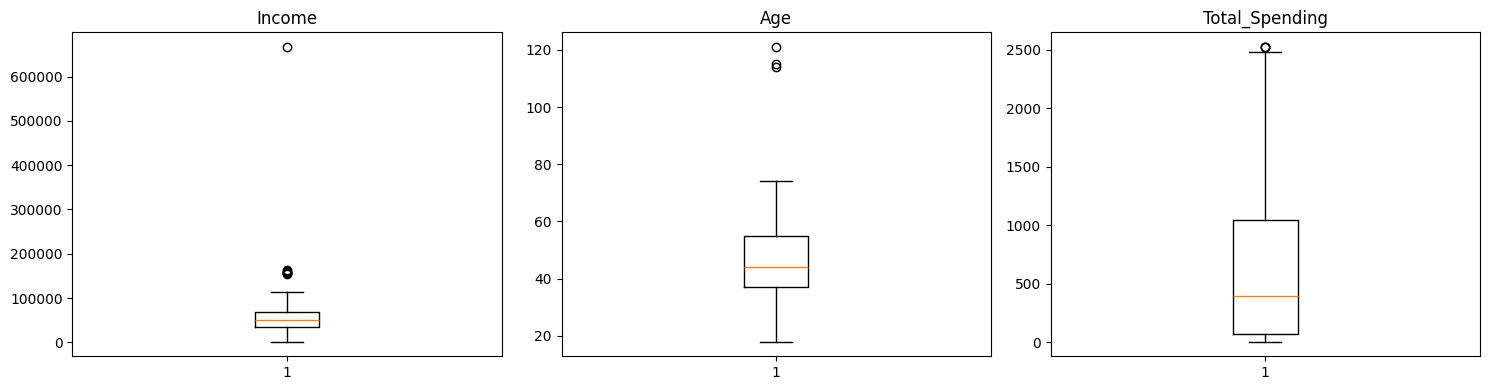

In [9]:
review_cols = ["Income", "Age", "Children", "Recency", "Total_Spending", "AcceptedTotal", "Customer_Days"]
display(data[review_cols].describe().T)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot(data["Income"].dropna())
axes[0].set_title("Income")

axes[1].boxplot(data["Age"].dropna())
axes[1].set_title("Age")

axes[2].boxplot(data["Total_Spending"].dropna())
axes[2].set_title("Total_Spending")

plt.tight_layout()
plt.show()

En estos boxplots se observa que algunas variables presentan valores atípicos. Esto significa que existen clientes cuyos valores están muy por encima o por debajo de la mayoría de los registros.

Por ejemplo, en `Income` aparecen algunos ingresos extremadamente altos en comparación con el resto. En `Age` se observan edades muy elevadas, que conviene revisar porque podrían representar casos poco comunes dentro del dataset. En `Total_Spending`, también hay clientes con un gasto mucho mayor al promedio, lo que puede indicar perfiles de alto valor.

Identificar estos valores es importante porque pueden influir en los resultados del clustering, sobre todo en K-Means, que trabaja con distancias. Aun así, no se eliminan de forma automática, ya que algunos pueden corresponder a clientes reales con comportamientos distintos y relevantes para la segmentación.

Aunque los valores atípicos pueden ser informativos en segmentación, en esta etapa se realiza una limpieza mínima de aquellos casos que resultan poco plausibles desde el punto de vista del negocio. En particular, se revisa la variable `Age`, ya que aparecen edades extremadamente altas que podrían afectar métodos sensibles a la distancia como K-Means. Esta depuración busca reducir ruido sin eliminar perfiles válidos de clientes con alto ingreso o alto gasto.

In [10]:
data[(data["Age"] < 18) | (data["Age"] > 100)][["Year_Birth", "Age"]]

,Year_Birth,Age
192,1900,114
239,1893,121
339,1899,115


Al revisar la variable `Age`, se identificaron tres registros con edades mayores a 100 años. Debido a que estos casos son poco plausibles en el contexto del análisis y podrían afectar la segmentación, se decidió eliminarlos. Esta depuración es mínima y busca reducir ruido sin alterar de forma importante la estructura general de los datos.

In [11]:
before = len(data)

data = data[(data["Age"] >= 18) & (data["Age"] <= 100)].copy()

after = len(data)
print("Registros eliminados:", before - after)

Registros eliminados: 3


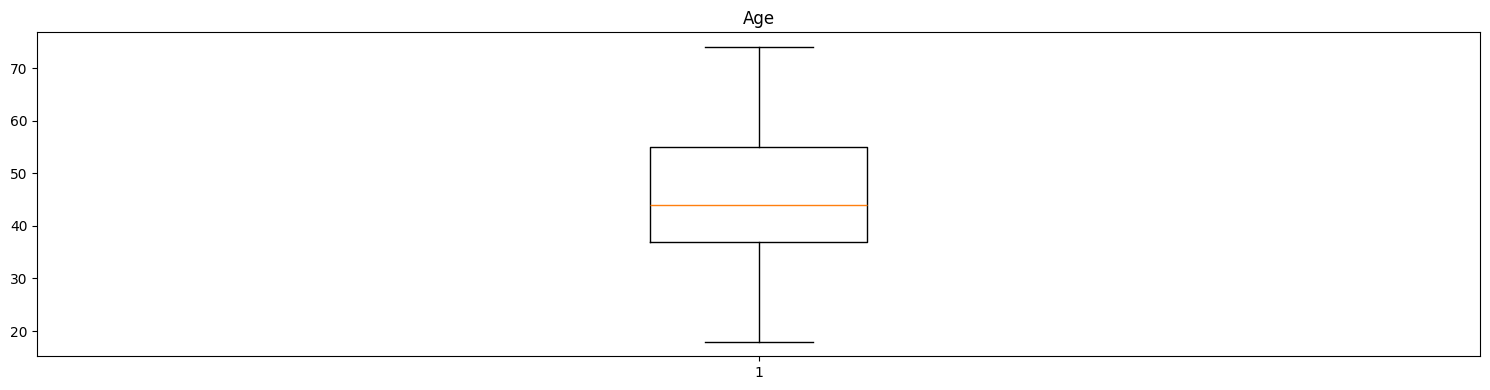

In [12]:

fig, axes = plt.subplots(1, 1, figsize=(15, 4))
axes.boxplot(data["Age"].dropna())
axes.set_title("Age")
plt.tight_layout()
plt.show()

### 5.4 Construcción de la matriz final

Con base en los criterios definidos en la sección anterior, se seleccionan las variables finales que se usarán para construir los clusters.


In [13]:
cluster_cols = [
    "Income",
    "Age",
    "Children",
    "Recency",
    "Total_Spending",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "AcceptedTotal",
    "Customer_Days"
]

X = data[cluster_cols].copy()

print("Dimensiones de la matriz para clustering:", X.shape)
display(X.head())

Dimensiones de la matriz para clustering: (2213, 12)


,Income,Age,Children,Recency,Total_Spending,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,AcceptedTotal,Customer_Days
0,"58,138.00",57,0,58,1617,8,10,4,3,7,1,663
1,"46,344.00",60,2,38,27,1,1,2,2,5,0,113
2,"71,613.00",49,0,26,776,8,2,10,1,4,0,312
3,"26,646.00",30,1,26,53,2,0,4,2,6,0,139
4,"58,293.00",33,1,94,422,5,3,6,5,5,0,161


### 5.5 Escalamiento de variables

Antes de aplicar K-Means y DBSCAN, es necesario escalar las variables numéricas. Esto se hace porque ambos algoritmos trabajan con distancias y podrían verse afectados por variables con magnitudes más grandes, como `Income` o `Total_Spending`.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Matriz escalada generada correctamente.")
print("Forma de X_scaled:", X_scaled.shape)

X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_cols)
display(X_scaled_df.head())

Matriz escalada generada correctamente.
Forma de X_scaled: (2213, 12)


,Income,Age,Children,Recency,Total_Spending,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,AcceptedTotal,Customer_Days
0,0.23,1.02,-1.26,0.31,1.68,1.43,2.50,-0.56,0.35,0.69,0.62,1.53
1,-0.23,1.28,1.40,-0.38,-0.96,-1.13,-0.57,-1.17,-0.17,-0.13,-0.50,-1.19
2,0.77,0.33,-1.26,-0.80,0.28,1.43,-0.23,1.29,-0.69,-0.55,-0.50,-0.21
3,-1.02,-1.29,0.07,-0.80,-0.92,-0.76,-0.91,-0.56,-0.17,0.28,-0.50,-1.06
4,0.24,-1.03,0.07,1.55,-0.31,0.33,0.11,0.06,1.39,-0.13,-0.50,-0.95


## 6. Aplicación de K-Means

Una vez preparada la matriz de datos, se aplica el algoritmo **K-Means** para identificar grupos de clientes con características similares. Este método busca formar clusters lo más homogéneos posible internamente y lo más diferentes posible entre sí.

Como K-Means requiere definir previamente el número de clusters, primero se evaluarán distintos valores de \(k\) con apoyo del método del codo y el índice de silhouette. Después, se seleccionará la solución que ofrezca un buen balance entre calidad técnica e interpretabilidad desde el punto de vista del negocio.

### 6.1 Evaluación del número de clusters

Para elegir un valor adecuado de \(k\), se comparan distintas soluciones mediante dos criterios:

- **Método del codo**: permite observar cómo disminuye la inercia al aumentar el número de clusters.
- **Silhouette score**: mide qué tan bien separados y compactos están los grupos.

La decisión final no se toma solo con base en la métrica, sino también en qué tan útiles e interpretables resultan los segmentos para el problema de negocio.

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Evaluación de distintos valores de k
k_values = list(range(2, 9))
inertias = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

metrics_kmeans = pd.DataFrame({
    "k": k_values,
    "inertia": inertias,
    "silhouette_score": sil_scores
})

display(metrics_kmeans)

,k,inertia,silhouette_score
0,2,"19,444.43",0.26
1,3,"17,113.47",0.22
2,4,"15,941.77",0.21
3,5,"15,002.57",0.14
4,6,"14,157.83",0.14
5,7,"13,644.08",0.13
6,8,"13,181.96",0.13


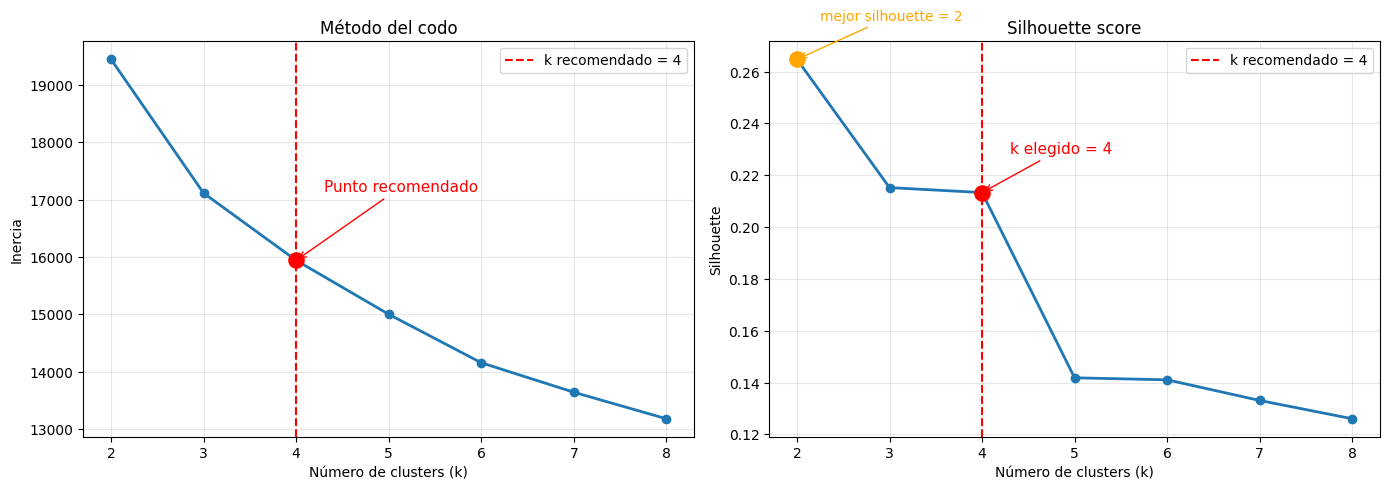

In [16]:
# k elegido por balance entre técnica e interpretabilidad
k_recomendado = 4

# k con mejor silhouette
k_silhouette = metrics_kmeans.loc[metrics_kmeans["silhouette_score"].idxmax(), "k"]

# valores para anotaciones
inercia_k = metrics_kmeans.loc[metrics_kmeans["k"] == k_recomendado, "inertia"].values[0]
sil_k = metrics_kmeans.loc[metrics_kmeans["k"] == k_recomendado, "silhouette_score"].values[0]
sil_best = metrics_kmeans["silhouette_score"].max()

# gráficas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(k_values, inertias, marker="o", linewidth=2)
axes[0].axvline(x=k_recomendado, color="red", linestyle="--", label=f"k recomendado = {k_recomendado}")
axes[0].scatter(k_recomendado, inercia_k, s=120, color="red", zorder=5)

axes[0].annotate(
    "Punto recomendado",
    xy=(k_recomendado, inercia_k),
    xytext=(k_recomendado + 0.3, inercia_k + 1200),
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red",
    fontsize=11
)

axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Silhouette score
axes[1].plot(k_values, sil_scores, marker="o", linewidth=2)
axes[1].axvline(x=k_recomendado, color="red", linestyle="--", label=f"k recomendado = {k_recomendado}")
axes[1].scatter(k_recomendado, sil_k, s=120, color="red", zorder=5)

axes[1].annotate(
    f"k elegido = {k_recomendado}",
    xy=(k_recomendado, sil_k),
    xytext=(k_recomendado + 0.3, sil_k + 0.015),
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red",
    fontsize=11
)

axes[1].scatter(k_silhouette, sil_best, s=120, color="orange", zorder=5)
axes[1].annotate(
    f"mejor silhouette = {k_silhouette}",
    xy=(k_silhouette, sil_best),
    xytext=(k_silhouette + 0.25, sil_best + 0.015),
    arrowprops=dict(arrowstyle="->", color="orange"),
    color="orange",
    fontsize=10
)

axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

A partir de los resultados obtenidos, se observa que el valor de silhouette más alto corresponde a \(k=2\), lo que indica una mejor separación global con un número pequeño de grupos. Sin embargo, el método del codo muestra que la reducción de la inercia sigue siendo relevante hasta alrededor de \(k=4\), y después las mejoras son cada vez menores.

Por esta razón, en este análisis se elige **\(k=4\)**. Aunque no es la opción con la mejor métrica de silhouette, sí ofrece un mejor balance entre calidad técnica e interpretación de negocio, ya que permite construir segmentos más diferenciados y útiles para marketing que una solución demasiado general de solo dos clusters.


### 6.2 Entrenamiento del modelo final

Con base en la evaluación anterior, se entrena el modelo final de K-Means con **\(k=4\)**, ya que esta opción ofrece un equilibrio razonable entre separación de grupos e interpretabilidad para el problema de negocio.

In [17]:
k_final = 4

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
data["Cluster_KMeans"] = kmeans_final.fit_predict(X_scaled)

print("Número de clusters:", k_final)

cluster_sizes = data["Cluster_KMeans"].value_counts().sort_index().to_frame(name="Cantidad de clientes")
display(cluster_sizes)

Número de clusters: 4


,Cantidad de clientes
Cluster_KMeans,
0,186
1,469
2,977
3,581


### 6.3 Perfil de los clusters

Para interpretar los segmentos, se analizan los promedios de las variables utilizadas en el clustering. Esto permite identificar diferencias en ingreso, gasto, comportamiento de compra, actividad digital y respuesta comercial entre los grupos encontrados.

In [18]:
profile_kmeans = data.groupby("Cluster_KMeans")[cluster_cols].mean().round(2)
display(profile_kmeans)

,Income,Age,Children,Recency,Total_Spending,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,AcceptedTotal,Customer_Days
Cluster_KMeans,,,,,,,,,,,,
0,"84,418.77",43.39,0.18,45.53,"1,636.20",5.64,6.49,7.71,1.20,3.37,2.66,397.43
1,"53,382.27",48.45,1.33,48.20,669.07,6.51,2.65,6.97,4.76,6.70,0.41,468.98
2,"34,297.11",42.23,1.22,49.20,90.70,2.02,0.52,3.17,1.86,6.39,0.17,311.62
3,"71,175.75",47.70,0.43,50.44,"1,095.69",5.11,5.08,8.69,1.49,3.04,0.25,317.52


In [19]:
profile_kmeans.style.background_gradient(cmap="YlGnBu").format("{:.2f}")

,Income,Age,Children,Recency,Total_Spending,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,AcceptedTotal,Customer_Days
Cluster_KMeans,,,,,,,,,,,,
0,84418.77,43.39,0.18,45.53,1636.20,5.64,6.49,7.71,1.20,3.37,2.66,397.43
1,53382.27,48.45,1.33,48.20,669.07,6.51,2.65,6.97,4.76,6.70,0.41,468.98
2,34297.11,42.23,1.22,49.20,90.70,2.02,0.52,3.17,1.86,6.39,0.17,311.62
3,71175.75,47.70,0.43,50.44,1095.69,5.11,5.08,8.69,1.49,3.04,0.25,317.52


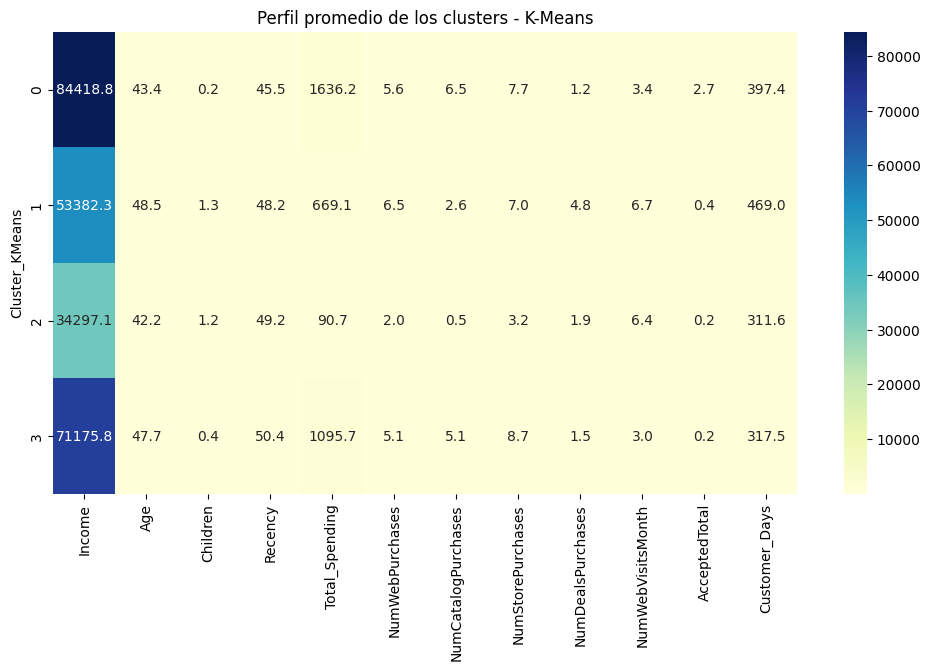

,Income,Age,Children,Recency,Total_Spending,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,AcceptedTotal,Customer_Days,Cantidad_Clientes
Cluster_KMeans,,,,,,,,,,,,,
0,"84,418.77",43.39,0.18,45.53,"1,636.20",5.64,6.49,7.71,1.20,3.37,2.66,397.43,186
1,"53,382.27",48.45,1.33,48.20,669.07,6.51,2.65,6.97,4.76,6.70,0.41,468.98,469
2,"34,297.11",42.23,1.22,49.20,90.70,2.02,0.52,3.17,1.86,6.39,0.17,311.62,977
3,"71,175.75",47.70,0.43,50.44,"1,095.69",5.11,5.08,8.69,1.49,3.04,0.25,317.52,581


,Income,Age,Children,Recency,Total_Spending,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,AcceptedTotal,Customer_Days,Cantidad_Clientes
Cluster_KMeans,,,,,,,,,,,,,
0,84418.77,43.39,0.18,45.53,1636.20,5.64,6.49,7.71,1.20,3.37,2.66,397.43,186.00
1,53382.27,48.45,1.33,48.20,669.07,6.51,2.65,6.97,4.76,6.70,0.41,468.98,469.00
2,34297.11,42.23,1.22,49.20,90.70,2.02,0.52,3.17,1.86,6.39,0.17,311.62,977.00
3,71175.75,47.70,0.43,50.44,1095.69,5.11,5.08,8.69,1.49,3.04,0.25,317.52,581.00


In [20]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(profile_kmeans, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Perfil promedio de los clusters - K-Means")
plt.show()

profile_summary = data.groupby("Cluster_KMeans")[cluster_cols].mean().round(2)
profile_summary["Cantidad_Clientes"] = data["Cluster_KMeans"].value_counts().sort_index()
display(profile_summary)

profile_summary.style.background_gradient(cmap="YlGnBu").format("{:.2f}")

Los resultados de K-Means permiten identificar cuatro grupos de clientes con diferencias importantes en ingreso, gasto, comportamiento de compra y respuesta comercial.

- **Cluster 0: Clientes premium multicanal.** Tienen el mayor ingreso, el mayor gasto y alta respuesta a campañas.
- **Cluster 1: Clientes sensibles a promociones.** Presentan gasto intermedio, muchas compras con descuento y alta actividad web.
- **Cluster 2: Clientes de bajo valor o en reactivación.** Muestran bajo ingreso, bajo gasto y poca respuesta comercial.
- **Cluster 3: Clientes de alto valor tradicional.** Tienen ingreso y gasto altos, pero compran más en tienda física y catálogo.

En general, esta segmentación permite distinguir perfiles útiles para apoyar decisiones de marketing y fidelización.

### 6.4 Visualización e interpretación inicial

Como la segmentación se realizó en un espacio de varias dimensiones, se utiliza **PCA** para proyectar los datos en dos componentes principales y facilitar la visualización de los clusters encontrados por K-Means.

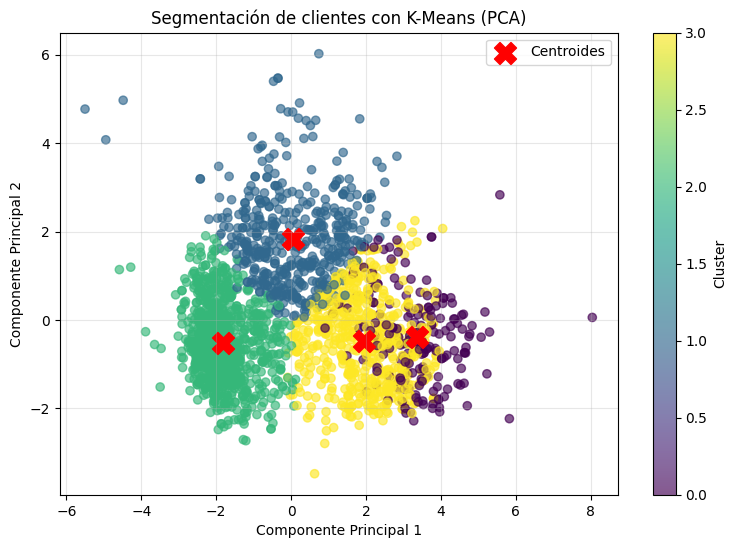

In [21]:
from sklearn.decomposition import PCA

# PCA a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

data["PCA1"] = X_pca[:, 0]
data["PCA2"] = X_pca[:, 1]

# Centroides del modelo en espacio PCA
centroids_scaled = kmeans_final.cluster_centers_
centroids_pca = pca.transform(centroids_scaled)

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    data["PCA1"],
    data["PCA2"],
    c=data["Cluster_KMeans"],
    cmap="viridis",
    alpha=0.65
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="red",
    s=250,
    marker="X",
    label="Centroides"
)

plt.title("Segmentación de clientes con K-Means (PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

La proyección con PCA muestra que la solución con 4 clusters genera grupos con una separación razonable en el espacio reducido a dos componentes principales. Aunque existe cierto traslape entre algunos segmentos, esto es esperable, ya que la segmentación original se realizó en un espacio de mayor dimensión y la proyección en dos componentes no conserva toda la información.

En general, la solución con \(k=4\) resulta adecuada porque permite distinguir perfiles diferentes de clientes de una manera útil para el análisis de negocio.

# Interpretación de Clusters - Segmentación de Clientes con K-Means

| Cluster | Nombre del Segmento | Características Clave | Perfil General | Comportamiento de Compra | Estrategia Recomendada |
|---------|----------------------|------------------------|----------------|--------------------------|------------------------|
| **0** | **Clientes premium multicanal** | • Mayor ingreso promedio<br>• Mayor gasto total<br>• Alta aceptación de campañas<br>• Uso equilibrado de web, catálogo y tienda | Clientes de alto valor, con poca carga familiar y buena relación comercial con la empresa | Compran con frecuencia por distintos canales y responden mejor que el resto a campañas y promociones | **Fidelización premium**:<br>• Beneficios exclusivos<br>• Programas VIP<br>• Cross-selling de productos de mayor valor<br>• Campañas personalizadas |
| **1** | **Clientes sensibles a promociones** | • Ingreso y gasto intermedios<br>• Muchas compras con descuento<br>• Alta actividad web<br>• Baja aceptación de campañas | Segmento con mayor antigüedad promedio y mayor presencia de hijos en el hogar | Son clientes activos, pero más orientados al precio y a los descuentos que a campañas tradicionales | **Promoción y conversión**:<br>• Cupones y descuentos temporales<br>• Remarketing digital<br>• Ofertas por tiempo limitado<br>• Incentivos por recompra |
| **2** | **Clientes de bajo valor o en reactivación** | • Menor ingreso promedio<br>• Gasto muy bajo<br>• Menor número de compras<br>• Muy baja respuesta comercial | Clientes con baja conversión y menor vínculo comercial con la empresa | Aunque visitan la web con relativa frecuencia, compran poco y casi no responden a campañas | **Reactivación o baja prioridad comercial**:<br>• Campañas de entrada<br>• Promociones básicas<br>• Productos accesibles<br>• Comunicación automatizada de bajo costo |
| **3** | **Clientes de alto valor tradicional** | • Ingreso alto<br>• Gasto elevado<br>• Preferencia por tienda física y catálogo<br>• Baja respuesta a campañas | Segmento valioso, con bajo número de hijos y comportamiento menos dependiente del canal digital | Compran bastante, especialmente en tienda física, pero no destacan por responder a campañas promocionales | **Fidelización tradicional**:<br>• Atención personalizada<br>• Beneficios por recurrencia<br>• Experiencia de compra preferencial<br>• Migración gradual a canales digitales |

## Observaciones generales

- La segmentación con K-Means permite distinguir perfiles con diferencias claras en ingreso, gasto, canal de compra y respuesta comercial.
- Los clusters **0** y **3** concentran a los clientes de mayor valor, aunque con comportamientos distintos: uno más multicanal y receptivo, y otro más tradicional.
- El cluster **1** representa una oportunidad para estrategias promocionales, mientras que el cluster **2** requiere acciones de reactivación o puede considerarse de menor prioridad comercial.

En conjunto, K-Means permite construir una segmentación útil de clientes a partir de variables relacionadas con ingreso, gasto, comportamiento de compra y respuesta comercial. Más allá de la separación matemática entre grupos, el valor del método en este caso radica en que los clusters obtenidos pueden traducirse en perfiles comprensibles y en acciones concretas para marketing y fidelización.

## 7. Aplicación de DBSCAN

Como complemento a K-Means, se aplicó **DBSCAN**, un método de clustering basado en densidad que permite identificar grupos naturales y también observaciones atípicas o ruido. A diferencia de K-Means, este algoritmo no requiere definir previamente el número de clusters.

### 7.1 Exploración de parámetros

DBSCAN depende principalmente de dos parámetros: `eps`, que define la distancia máxima entre vecinos, y `min_samples`, que indica el número mínimo de puntos necesarios para formar una región densa. Como apoyo inicial, se revisa la gráfica de distancias k.

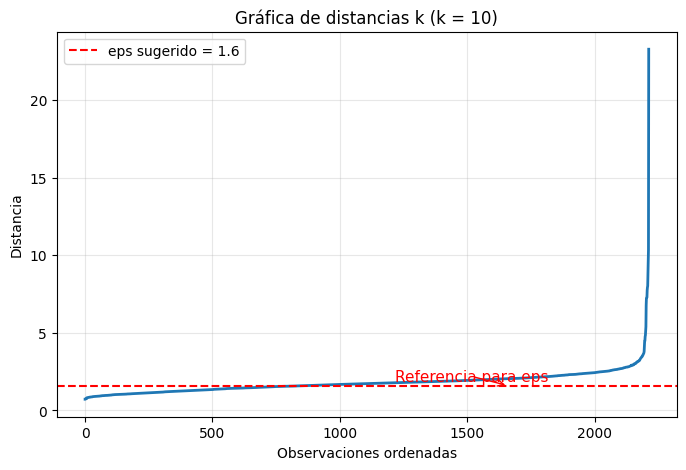

In [22]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples_ref = 10

neighbors = NearestNeighbors(n_neighbors=min_samples_ref)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Distancia al vecino k
k_distances = np.sort(distances[:, min_samples_ref - 1])

# Valor sugerido inicial de eps
eps_sugerido = 1.6

plt.figure(figsize=(8, 5))
plt.plot(k_distances, linewidth=2)
plt.axhline(y=eps_sugerido, color="red", linestyle="--", label=f"eps sugerido = {eps_sugerido}")

plt.annotate(
    "Referencia para eps",
    xy=(len(k_distances) * 0.75, eps_sugerido),
    xytext=(len(k_distances) * 0.55, eps_sugerido + 0.3),
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red",
    fontsize=11
)

plt.title(f"Gráfica de distancias k (k = {min_samples_ref})")
plt.xlabel("Observaciones ordenadas")
plt.ylabel("Distancia")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


La gráfica anterior se utiliza como referencia inicial para proponer valores de `eps`. A partir de ella, se probaron distintas combinaciones de parámetros para evaluar qué tan estable y útil resultaba la segmentación.

### 7.2 Comparación de configuraciones

Se evaluaron varias combinaciones de `eps` y `min_samples`, considerando el número de clusters encontrados, la proporción de ruido y el silhouette score cuando fue posible.

In [23]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

eps_values = [1.2, 1.4, 1.6, 1.8, 2.0]
min_samples_values = [8, 10, 12]

results_dbscan = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_noise = np.sum(labels == -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = n_noise / len(labels)

        cluster_sizes = pd.Series(labels)
        cluster_sizes = cluster_sizes[cluster_sizes != -1].value_counts()
        min_cluster_size = int(cluster_sizes.min()) if len(cluster_sizes) > 0 else 0

        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask])
        else:
            sil = np.nan

        results_dbscan.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_ratio": round(noise_ratio, 4),
            "min_cluster_size": min_cluster_size,
            "silhouette_score": sil
        })

results_dbscan = pd.DataFrame(results_dbscan).sort_values(
    by=["n_clusters", "silhouette_score", "noise_ratio"],
    ascending=[False, False, True]
)

display(results_dbscan)


,eps,min_samples,n_clusters,n_noise,noise_ratio,min_cluster_size,silhouette_score
3,1.40,8,6,1273,0.58,8,0.07
8,1.60,12,5,963,0.44,6,0.12
5,1.40,12,5,1409,0.64,12,0.06
4,1.40,10,5,1361,0.61,12,0.06
7,1.60,10,3,877,0.40,7,0.22
0,1.20,8,3,1628,0.74,11,0.14
6,1.60,8,3,812,0.37,5,0.12
9,1.80,8,3,438,0.20,8,0.01
10,1.80,10,2,516,0.23,8,0.28
11,1.80,12,2,576,0.26,10,0.21


En general, se observó que con valores bajos de `eps` aumentaba el número de clusters, pero también la cantidad de ruido. En cambio, con valores más altos, el ruido disminuía, aunque la estructura tendía a concentrarse en uno o dos grupos principales.

In [24]:
refined_results = []

for eps in [1.7, 1.8, 1.9]:
    for min_samples in [8, 10, 12]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_noise = np.sum(labels == -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = n_noise / len(labels)

        cluster_sizes = pd.Series(labels)
        cluster_sizes = cluster_sizes[cluster_sizes != -1].value_counts()
        min_cluster_size = int(cluster_sizes.min()) if len(cluster_sizes) > 0 else 0

        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask])
        else:
            sil = np.nan

        refined_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_ratio": round(noise_ratio, 4),
            "min_cluster_size": min_cluster_size,
            "silhouette_score": sil
        })

refined_results = pd.DataFrame(refined_results).sort_values(
    by=["silhouette_score", "n_clusters", "noise_ratio"],
    ascending=[False, False, True]
)

display(refined_results)


,eps,min_samples,n_clusters,n_noise,noise_ratio,min_cluster_size,silhouette_score
4,1.80,10,2,516,0.23,8,0.28
5,1.80,12,2,576,0.26,10,0.21
2,1.70,12,2,747,0.34,10,0.21
0,1.70,8,3,610,0.28,8,0.04
3,1.80,8,3,438,0.20,8,0.01
7,1.90,10,2,362,0.16,9,0.01
6,1.90,8,1,327,0.15,1886,NaN
8,1.90,12,1,409,0.18,1804,NaN
1,1.70,10,1,692,0.31,1521,NaN


### 7.3 Modelo final y distribución

Con base en la comparación anterior, se seleccionó la combinación de parámetros que ofrecía el mejor balance entre número de clusters, proporción de ruido e interpretabilidad.

In [25]:
# Selección del conjunto de resultados a considerar
if "refined_results" in globals() and len(refined_results) > 0:
    resultados_base = refined_results.copy()
else:
    resultados_base = results_dbscan.copy()

# Criterios de estabilidad: al menos 2 clusters, ruido moderado y sin clusters mínimos demasiado pequeños
candidatos = resultados_base[
    (resultados_base["n_clusters"] >= 2) &
    (resultados_base["noise_ratio"] < 0.35) &
    (resultados_base["min_cluster_size"] >= 30)
].copy()

if len(candidatos) > 0:
    candidatos = candidatos.sort_values(
        by=["silhouette_score", "noise_ratio", "n_clusters"],
        ascending=[False, True, False]
    )
    eps_final = float(candidatos.iloc[0]["eps"])
    min_samples_final = int(candidatos.iloc[0]["min_samples"])
    criterio_seleccion = "configuración estable"
else:
    # Si no existe una solución estable, se conserva la combinación con mejor balance técnico observado
    respaldo = resultados_base[
        (resultados_base["n_clusters"] >= 2)
    ].sort_values(
        by=["silhouette_score", "noise_ratio"],
        ascending=[False, True]
    )
    eps_final = float(respaldo.iloc[0]["eps"])
    min_samples_final = int(respaldo.iloc[0]["min_samples"])
    criterio_seleccion = "mejor balance técnico disponible"

print("Parámetros seleccionados para DBSCAN:")
print("eps =", eps_final)
print("min_samples =", min_samples_final)
print("Criterio de selección:", criterio_seleccion)


Parámetros seleccionados para DBSCAN:
eps = 1.8
min_samples = 10
Criterio de selección: mejor balance técnico disponible


In [26]:
dbscan_final = DBSCAN(eps=eps_final, min_samples=min_samples_final)
data["Cluster_DBSCAN"] = dbscan_final.fit_predict(X_scaled)

n_clusters_final = len(set(data["Cluster_DBSCAN"])) - (1 if -1 in data["Cluster_DBSCAN"].values else 0)
n_noise_final = (data["Cluster_DBSCAN"] == -1).sum()
noise_ratio_final = n_noise_final / len(data)

print("Modelo DBSCAN entrenado correctamente.")
print("Número de clusters encontrados:", n_clusters_final)
print("Cantidad de observaciones ruido:", n_noise_final)
print("Proporción de ruido:", round(noise_ratio_final, 4))

Modelo DBSCAN entrenado correctamente.
Número de clusters encontrados: 2
Cantidad de observaciones ruido: 516
Proporción de ruido: 0.2332


Una vez entrenado el modelo, se revisa la cantidad de observaciones asignadas a cada cluster y el número de casos clasificados como ruido.

,Cantidad de clientes
Cluster_DBSCAN,
-1,516
0,1689
1,8


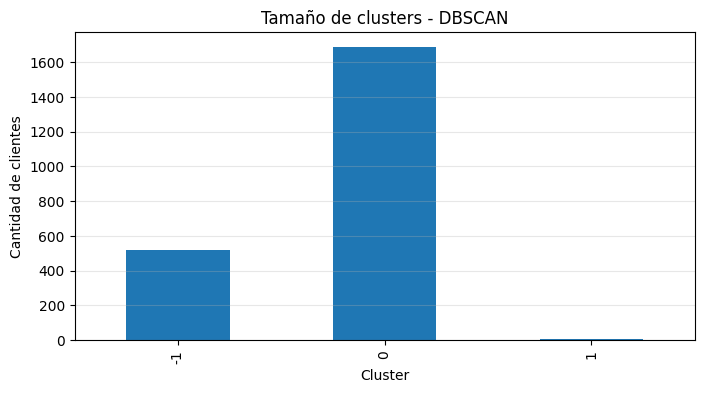

In [27]:
cluster_sizes_dbscan = (
    data["Cluster_DBSCAN"]
    .value_counts()
    .sort_index()
    .to_frame(name="Cantidad de clientes")
)

display(cluster_sizes_dbscan)

plt.figure(figsize=(8, 4))
cluster_sizes_dbscan["Cantidad de clientes"].plot(kind="bar")
plt.title("Tamaño de clusters - DBSCAN")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de clientes")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

### 7.4 Perfil e interpretación

Para interpretar los grupos encontrados por DBSCAN, se calculan los promedios de las variables utilizadas en el clustering. El ruido (`-1`) se conserva en el análisis, ya que representa observaciones con comportamiento atípico o de baja densidad.

In [28]:
profile_dbscan = data.groupby("Cluster_DBSCAN")[cluster_cols].mean().round(2)
display(profile_dbscan)

profile_dbscan.style.background_gradient(cmap="Oranges").format("{:.2f}")

,Income,Age,Children,Recency,Total_Spending,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,AcceptedTotal,Customer_Days
Cluster_DBSCAN,,,,,,,,,,,,
-1,"69,253.18",46.59,0.66,47.08,"1,179.06",5.89,5.15,7.55,2.67,4.97,1.26,402.74
0,"46,908.56",44.68,1.04,49.75,427.17,3.53,1.90,5.26,2.23,5.44,0.19,338.77
1,"79,544.00",33.38,0.00,17.12,"1,682.12",5.00,5.25,8.50,1.00,2.25,2.88,351.50


,Income,Age,Children,Recency,Total_Spending,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,AcceptedTotal,Customer_Days
Cluster_DBSCAN,,,,,,,,,,,,
-1,69253.18,46.59,0.66,47.08,1179.06,5.89,5.15,7.55,2.67,4.97,1.26,402.74
0,46908.56,44.68,1.04,49.75,427.17,3.53,1.90,5.26,2.23,5.44,0.19,338.77
1,79544.00,33.38,0.00,17.12,1682.12,5.00,5.25,8.50,1.00,2.25,2.88,351.50


A partir del perfil promedio de los grupos encontrados por DBSCAN, se observa una estructura menos segmentada que la obtenida con K-Means.

- **Cluster 0** concentra a la mayoría de los clientes y representa un perfil de valor intermedio, con gasto moderado, menor respuesta a campañas y mayor actividad web.
- **Cluster 1** agrupa un número muy reducido de clientes, pero con ingreso alto, gasto elevado, baja recencia y alta aceptación de campañas. Este grupo puede interpretarse como un conjunto atípico de clientes de muy alto valor.
- **Ruido (-1)** incluye observaciones que no pertenecen claramente a una región densa. En este caso, no necesariamente representan errores, sino clientes con comportamientos más heterogéneos o menos compactos.

En conjunto, estos resultados sugieren que DBSCAN es útil para detectar clientes atípicos, pero menos adecuado para generar segmentos amplios y balanceados con fines operativos de marketing.

### 7.5 Visualización de DBSCAN con PCA

Al igual que en K-Means, se proyectan los datos en dos componentes principales para visualizar la estructura general de los clusters encontrados por DBSCAN. En esta gráfica, el valor **-1** representa observaciones clasificadas como ruido.

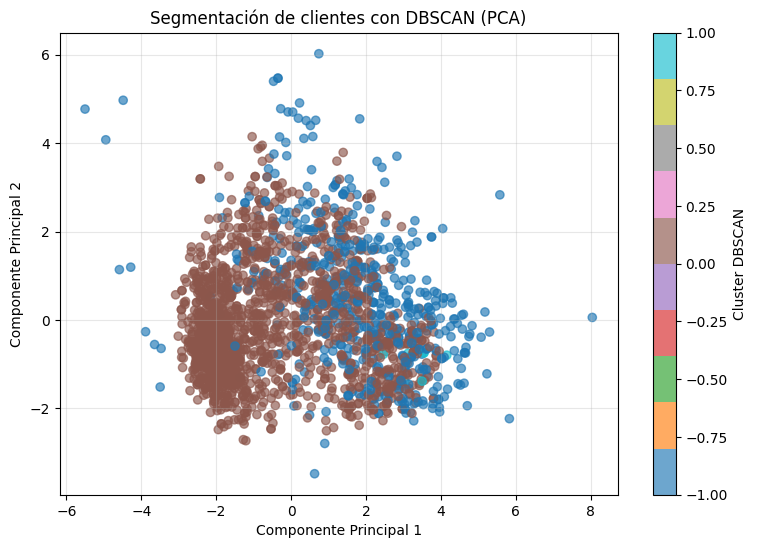

In [29]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    data["PCA1"],
    data["PCA2"],
    c=data["Cluster_DBSCAN"],
    cmap="tab10",
    alpha=0.65
)

plt.title("Segmentación de clientes con DBSCAN (PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.colorbar(scatter, label="Cluster DBSCAN")
plt.grid(True, alpha=0.3)
plt.show()

La visualización con PCA confirma que DBSCAN no genera varios grupos amplios y claramente separados. En cambio, se observa una concentración principal de clientes, un pequeño grupo diferenciado y un conjunto de observaciones dispersas clasificadas como ruido.

# Interpretación de Clusters - Segmentación de Clientes con DBSCAN

| Cluster | Nombre del Segmento | Características Clave | Interpretación | Estrategia Recomendada |
|---------|----------------------|------------------------|----------------|------------------------|
| **0** | **Grupo principal de valor intermedio** | • Ingreso medio<br>• Gasto moderado<br>• Baja aceptación de campañas<br>• Mayor actividad web | Representa a la mayoría de los clientes y concentra perfiles de valor intermedio, con comportamiento menos receptivo a campañas. | **Marketing general y segmentación base**:<br>• Comunicación segmentada<br>• Promociones selectivas<br>• Incentivos de conversión |
| **1** | **Clientes atípicos de muy alto valor** | • Ingreso alto<br>• Gasto muy alto<br>• Baja recencia<br>• Alta aceptación de campañas | Es un grupo muy pequeño pero valioso, con comportamiento diferenciado respecto al resto. | **Atención prioritaria**:<br>• Fidelización premium<br>• Seguimiento personalizado<br>• Beneficios exclusivos |
| **-1** | **Ruido / clientes no agrupados** | • Comportamiento heterogéneo<br>• Ingreso y gasto relativamente altos<br>• No forman una región densa clara | No necesariamente representan errores, sino clientes con patrones menos compactos o más dispersos. | **Análisis complementario**:<br>• Revisión individual o exploratoria<br>• Identificación de perfiles especiales<br>• Uso como alerta de atipicidad |

### Conclusión de DBSCAN

En este análisis, DBSCAN aportó valor principalmente por su capacidad para detectar clientes atípicos y mostrar la presencia de ruido en los datos. Sin embargo, la segmentación obtenida fue menos clara y menos balanceada que la de K-Means, por lo que su utilidad resulta más complementaria que principal para fines de marketing.

## 8. Comparación entre K-Means y DBSCAN

Los dos métodos aplicados mostraron resultados diferentes. Por un lado, **K-Means** permitió construir una segmentación en **cuatro grupos** con diferencias claras en ingreso, gasto, comportamiento de compra y respuesta comercial. Esto hizo posible interpretar los clusters de forma útil para marketing.

Por otro lado, **DBSCAN** generó una estructura menos balanceada, con un grupo principal, un grupo muy pequeño y una cantidad importante de observaciones clasificadas como ruido. Esto indica que, en este dataset, DBSCAN fue más útil para detectar clientes atípicos que para construir una segmentación comercial amplia.

En términos generales, **K-Means resultó más adecuado como método principal de segmentación**, ya que produjo grupos más interpretables y accionables. En cambio, **DBSCAN aportó valor como herramienta complementaria**, al permitir identificar observaciones poco comunes y analizar la presencia de ruido en los datos.

## 9. Recomendaciones de negocio y conclusión ejecutiva

A partir de la segmentación obtenida con K-Means, se pueden proponer acciones diferenciadas para cada grupo de clientes. Los **clientes premium multicanal** pueden atenderse con estrategias de fidelización, beneficios exclusivos y campañas personalizadas. Los **clientes sensibles a promociones** requieren descuentos, cupones y acciones de remarketing. Los **clientes de bajo valor o en reactivación** pueden abordarse con campañas de reactivación y comunicación de bajo costo. Finalmente, los **clientes de alto valor tradicional** pueden beneficiarse de atención personalizada y estrategias enfocadas en tienda física y catálogo.

En conclusión, el análisis demuestra que la empresa no debería tratar a todos sus clientes de la misma forma. La segmentación permitió identificar perfiles con comportamientos distintos y traducirlos en acciones concretas de marketing. En este caso, **K-Means ofreció la solución más útil para el negocio**, mientras que **DBSCAN complementó el análisis al detectar clientes atípicos y ruido**.

## Conclusión final

En este trabajo se aplicaron dos métodos de clustering, **K-Means** y **DBSCAN**, para segmentar clientes a partir de su perfil y comportamiento de compra. Los resultados mostraron que **K-Means** fue el método más útil para este caso, ya que permitió identificar grupos más claros, interpretables y aplicables a estrategias de marketing.

Por su parte, **DBSCAN** resultó valioso como herramienta complementaria, principalmente para detectar clientes atípicos y observar la presencia de ruido en los datos. En conjunto, el análisis confirma que la segmentación puede ayudar a la empresa a dejar de tratar igual a todos sus clientes y a diseñar acciones más específicas según las características de cada grupo.